# XGBoost — CPU vs GPU

XGBoost has first-class GPU support via `device='cuda'` (since 2.0). On a single-node workflow,
the only thing you change is one parameter; the rest of the API is identical.

This notebook:
1. Trains an identical model on CPU and GPU and times both.
2. **Scales the dataset** and plots how the speedup grows with size.
3. Confirms that accuracy is preserved (same algorithm, same hyperparameters).
4. Visualises feature importance from the GPU model.

In [1]:
import xgboost as xgb
import numpy as np
import time, matplotlib.pyplot as plt

print(f"XGBoost version: {xgb.__version__}")

XGBoost version: 2.1.4


## 1. Build a baseline dataset (500k rows, 30 features)

In [2]:
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split

X, y = make_classification(
    n_samples=500_000, n_features=30, n_informative=15, random_state=42,
)
X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.2, random_state=42)
dtrain = xgb.DMatrix(X_tr, label=y_tr)
dtest  = xgb.DMatrix(X_te, label=y_te)
print(f"Train: {X_tr.shape}  |  Test: {X_te.shape}")

Train: (400000, 30)  |  Test: (100000, 30)


## 2. CPU vs GPU training time — same hyperparameters

We use `tree_method='hist'` and only change `device`.

In [3]:
from sklearn.metrics import roc_auc_score

params_base = dict(
    max_depth=8, eta=0.1,
    objective="binary:logistic", eval_metric="logloss",
    tree_method="hist", seed=42,
)

t0 = time.perf_counter()
model_cpu = xgb.train({**params_base, "device": "cpu"}, dtrain, num_boost_round=200, verbose_eval=False)
t_cpu = time.perf_counter() - t0
auc_cpu = roc_auc_score(y_te, model_cpu.predict(dtest))

t0 = time.perf_counter()
model_gpu = xgb.train({**params_base, "device": "cuda"}, dtrain, num_boost_round=200, verbose_eval=False)
t_gpu = time.perf_counter() - t0
auc_gpu = roc_auc_score(y_te, model_gpu.predict(dtest))

print(f"{'':10s}  {'Time':>8s}   {'AUC':>8s}")
print(f"{'CPU':10s}  {t_cpu:7.2f}s  {auc_cpu:8.4f}")
print(f"{'GPU':10s}  {t_gpu:7.2f}s  {auc_gpu:8.4f}   (speedup {t_cpu/t_gpu:.1f}x)")

                Time        AUC
CPU            6.28s    0.9935
GPU            3.32s    0.9936   (speedup 1.9x)


## 3. Scaling — how the speedup grows with dataset size

Tree boosting has high constant per-tree overhead on CPU; on GPU the histogram construction is hugely parallel,
so the gap widens with the number of rows.

n=   50,000  CPU=  0.99s  GPU= 1.05s  speedup=  1.0x
n=  100,000  CPU=  1.34s  GPU= 1.20s  speedup=  1.1x
n=  250,000  CPU=  2.53s  GPU= 1.53s  speedup=  1.7x
n=  500,000  CPU=  4.07s  GPU= 1.80s  speedup=  2.3x
n=1,000,000  CPU=  7.56s  GPU= 2.32s  speedup=  3.3x


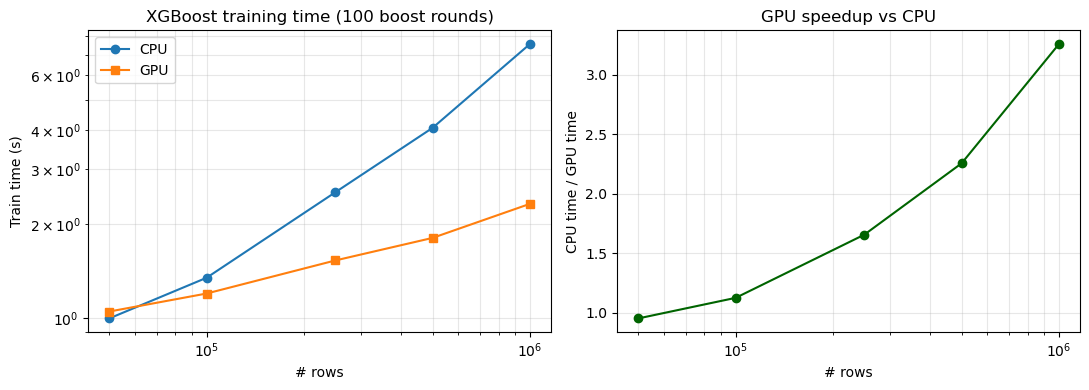

In [4]:
sizes = [50_000, 100_000, 250_000, 500_000, 1_000_000]
cpu_times, gpu_times = [], []
for n in sizes:
    Xs, ys = make_classification(n_samples=n, n_features=30, n_informative=15, random_state=42)
    d = xgb.DMatrix(Xs, label=ys)

    t0 = time.perf_counter()
    xgb.train({**params_base, "device": "cpu"}, d, num_boost_round=100, verbose_eval=False)
    cpu_times.append(time.perf_counter() - t0)

    t0 = time.perf_counter()
    xgb.train({**params_base, "device": "cuda"}, d, num_boost_round=100, verbose_eval=False)
    gpu_times.append(time.perf_counter() - t0)
    print(f"n={n:>9,d}  CPU={cpu_times[-1]:6.2f}s  GPU={gpu_times[-1]:5.2f}s  speedup={cpu_times[-1]/gpu_times[-1]:5.1f}x")

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].loglog(sizes, cpu_times, "o-", label="CPU")
axes[0].loglog(sizes, gpu_times, "s-", label="GPU")
axes[0].set_xlabel("# rows"); axes[0].set_ylabel("Train time (s)")
axes[0].set_title("XGBoost training time (100 boost rounds)"); axes[0].legend(); axes[0].grid(True, which="both", alpha=0.3)
axes[1].semilogx(sizes, [c/g for c, g in zip(cpu_times, gpu_times)], "o-", color="darkgreen")
axes[1].set_xlabel("# rows"); axes[1].set_ylabel("CPU time / GPU time")
axes[1].set_title("GPU speedup vs CPU"); axes[1].grid(True, which="both", alpha=0.3)
plt.tight_layout(); plt.show()

## 4. Feature importance from the GPU model

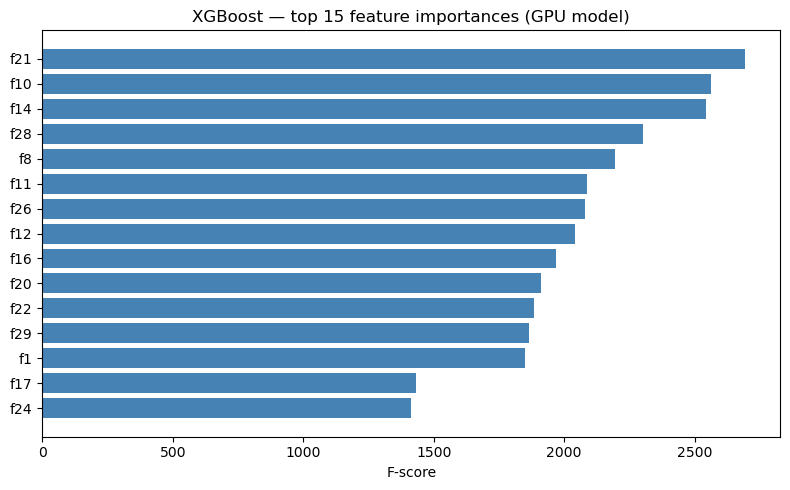

In [5]:
scores = model_gpu.get_fscore()
top = sorted(scores.items(), key=lambda x: x[1], reverse=True)[:15]
names, values = zip(*top)

plt.figure(figsize=(8, 5))
plt.barh(names[::-1], values[::-1], color="steelblue")
plt.xlabel("F-score"); plt.title("XGBoost — top 15 feature importances (GPU model)")
plt.tight_layout(); plt.show()